General Stationary Spacetimes: KHZM

In [14]:
import numpy as np
import math
import scipy.optimize

import pandas as pd
import csv
import statistics

import warnings

from alive_progress import alive_bar
import time

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
from matplotlib import rcParams

###########################################################################################
###########################################################################################

# EHT Constraints

# EHT M87* Paper VI, Psaltis+20, Kocherlakota+21

delta_Min_M87 = -0.18 
delta_Max_M87 = +0.16 

etaps_Min_M87 = 3.*np.sqrt(3.)*(1.+delta_Min_M87)
etaps_Max_M87 = 3.*np.sqrt(3.)*(1.+delta_Max_M87)

#####################################################################################
#####################################################################################

# EHT M87* Paper VI, KECK+ehtim+KH-GRMHD

delta_Min_SgrA = -0.14 
delta_Max_SgrA = +0.05  

etaps_Min_SgrA = 3.*np.sqrt(3.)*(1.+delta_Min_SgrA)
etaps_Max_SgrA = 3.*np.sqrt(3.)*(1.+delta_Max_SgrA)

###########################################################################################
###########################################################################################

# Resolutions for Root-Finding, Grids etc.

res16    = 1.e-16
res8     = 5.*np.sqrt(res16)
res_grid = 1.e-2

In [15]:
###########################################################################################
# KHZM4 Metric Functions 1
###########################################################################################

def Delta(r, metric_params):
    ########################################
    a = float(metric_params[0])
    l = float(metric_params[1])
    r = float(r)
    ########################################
    return float(r**2 - 2.*r**5/(r**4 + 2.*l**4) + a**2)

def dDeltadr(r, metric_params):
    ########################################
    a = float(metric_params[0])
    l = float(metric_params[1])
    r = float(r)
    ########################################
    return float((2.*r**9 - 2.*r**8 + 8.*l**4*r**5 - 20.*l**4*r**4 + 8.*l**8*r)/(r**4 + 2.*l**4)**2)

def d2Deltadr2(r, metric_params):
    ########################################
    a = float(metric_params[0])
    l = float(metric_params[1])
    r = float(r)
    ########################################
    return float(2. + (16.*r**3*(3.*l**4*r**4 - 10.*l**8))/(r**4 + 2.*l**4)**3)

###########################################################################################
# Horizon Radius

def rH(metric_params):
    ########################################
    def rH_Eq(r):
        return Delta(r, metric_params)
    # rH_Sol = scipy.optimize.newton(rH_Eq, 2.5, fprime=, tol=res8)
    # rH_Sol = fsolve(rH_Eq, 2.5, xtol=res16)[0]
    rH_Sol = scipy.optimize.root(rH_Eq, 2.5, tol=res16).x
    ########################################
    return float(rH_Sol)

###########################################################################################
# Extremal BHs

lMax = (27./32.)**(0.25)

def a_Max(metric_params):
    l_Val = float(metric_params[1])
    def Eqs(a_r):
        a, r = a_r
        return (Delta(r, [a, l_Val]), dDeltadr(r, [a, l_Val]))
    a_Val, r_Val = scipy.optimize.fsolve(Eqs, (0.5, 2.))
    return float(np.abs(a_Val))

def l_Max(metric_params):
    a_Val = float(metric_params[0])
    def Eqs(l_r):
        l, r = l_r
        return (Delta(r, [a_Val, l]), dDeltadr(r, [a_Val, l]))
    l_Val, r_Val = scipy.optimize.fsolve(Eqs, (0.5, 2.))
    return float(np.abs(l_Val))

###########################################################################################
# KHZM4 Metric Functions 2
###########################################################################################

def f(r, metric_params):
    f_Val = 0.
    ########################################
    return float(f_Val)

def Sigma(r, th, metric_params): 
    ########################################
    a = float(metric_params[0])
    r = float(r)
    y = float(np.cos(float(th)))            # defining y=cos(\theta)
    ########################################
    Sigma_Val = r**2 + f(r, metric_params) + a**2*y**2
    ########################################
    return float(Sigma_Val)

###########################################################################################

def F(r, metric_params):
    ########################################
    a = float(metric_params[0])
    r = float(r)
    ########################################    
    return float(r/(r**2 + a**2))

def dFdr(r, metric_params):
    ########################################
    a = float(metric_params[0])
    r = float(r)
    ########################################
    return float(-(r**2 - a**2)/(r**2 + a**2)**2)

def d2Fdr2(r, metric_params):
    ########################################
    a = float(metric_params[0])
    r = float(r)
    ########################################
    return float(2.*(r**3 - 3.*a**2*r)/(r**2 + a**2)**3)

In [ ]:
###########################################################################################
# Remaining Metric Functions [defined using the ones above for a number of spacetimes; see Table 1 of Salehi et al. (2023)]
###########################################################################################
# Used: B = F r

def B(r, metric_params):
    return float(r*F(r, metric_params))

def dBdr(r, metric_params):
    return float(F(r, metric_params) + r*dFdr(r, metric_params))

def d2Bdr2(r, metric_params):
    return float(2.*dFdr(r, metric_params) + r*d2Fdr2(r, metric_params))

###########################################################################################
# Used: N = F \sqrt(Delta)

def N(r, metric_params):
    ###################################
    rt_Delta_Val = np.sqrt(Delta(r, metric_params) + 0.j)
    ###################################
    N_Val_Re = F(r, metric_params)*(rt_Delta_Val.real)
    ###################################
    if np.abs(rt_Delta_Val.imag) <= res8:
        imag_chk = 0
    else:
        imag_chk = 1
    ###################################
    return [float(N_Val_Re), imag_chk]

def dNdr(r, metric_params):
    ###################################
    numerator_Val = F(r, metric_params)*dDeltadr(r, metric_params) + 2.*dFdr(r, metric_params)*Delta(r, metric_params)
    ###################################
    rt_Delta_Val       = np.sqrt(Delta(r, metric_params) + 0j)
    denominator_Val_Re = 2.*rt_Delta_Val.real
    ###################################
    dNdr_Val_Re = numerator_Val/denominator_Val_Re
    ###################################
    if np.abs(rt_Delta_Val.imag) <= res8:
        imag_chk = 0
    else:
        imag_chk = 1    
    ###################################
    return [float(dNdr_Val_Re), imag_chk]

def d2Ndr2(r, metric_params):
    ###################################
    numerator_Val_t1 = -F(r, metric_params)*dDeltadr(r, metric_params)**2 + 4.*d2Fdr2(r, metric_params)*Delta(r, metric_params)**2
    numerator_Val_t2 = 2.*Delta(r, metric_params)*(2.*dFdr(r, metric_params)*dDeltadr(r, metric_params) + F(r, metric_params)*d2Deltadr2(r, metric_params))
    ###################################
    rt_Delta_Val       = np.sqrt(Delta(r, metric_params) + 0j)
    denominator_Val_Re = 4.*(rt_Delta_Val.real)**3
    ###################################
    d2Ndr2_Val_Re = (numerator_Val_t1+numerator_Val_t2)/denominator_Val_Re
    ###################################
    if np.abs(rt_Delta_Val.imag) <= res8:
        imag_chk = 0
    else:
        imag_chk = 1    
    ###################################
    return [float(d2Ndr2_Val_Re), imag_chk]

###########################################################################################

def metric_funcs(r, metric_params):
    ###################################
    F_Val          = F(     r, metric_params)
    dFdr_Val       = dFdr(  r, metric_params)
    d2Fdr2_Val     = d2Fdr2(r, metric_params)
    ###################################
    N_Val          = N(     r, metric_params)[0]
    dNdr_Val       = dNdr(  r, metric_params)[0]
    d2Ndr2_Val     = d2Ndr2(r, metric_params)[0]
    ###################################
    B_Val          = B(     r, metric_params)
    dBdr_Val       = dBdr(  r, metric_params)
    d2Bdr2_Val     = d2Bdr2(r, metric_params)
    ###################################
    N_Val_chk      = N(     r, metric_params)[1]
    dNdr_Val_chk   = dNdr(  r, metric_params)[1]
    d2Ndr2_Val_chk = d2Ndr2(r, metric_params)[1]
    ###################################
    return [F_Val, dFdr_Val, d2Fdr2_Val, N_Val, dNdr_Val, d2Ndr2_Val, B_Val, dBdr_Val, d2Bdr2_Val, N_Val_chk, dNdr_Val_chk, d2Ndr2_Val_chk]

###########################################################################################
# Impact Parameters of Spherical Null Geodesics (SNGs)
###########################################################################################

def xi_SNG(r, metric_params):
    ###################################
    a = float(metric_params[0])
    ###################################
    if np.abs(a) <= res8: a = res8
    metric_params[0] = a
    ###################################
    metric_funcs_Vals = metric_funcs(r, metric_params)
    ###################################
    F_Val      = metric_funcs_Vals[0]
    dFdr_Val   = metric_funcs_Vals[1]
    d2Fdr2_Val = metric_funcs_Vals[2]
    ###################################
    N_Val      = metric_funcs_Vals[3]
    dNdr_Val   = metric_funcs_Vals[4]
    d2Ndr2_Val = metric_funcs_Vals[5]
    ###################################
    B_Val      = metric_funcs_Vals[6]
    dBdr_Val   = metric_funcs_Vals[7]
    d2Bdr2_Val = metric_funcs_Vals[8]
    ###################################
    numerator_Val   = N_Val - r*dNdr_Val
    denominator_Val = a*(N_Val*dFdr_Val - F_Val*dNdr_Val)
    ###################################
    return float(numerator_Val/denominator_Val) 
    
def eta_SNG(r, metric_params): # eta appears in all expressions as a squared quantity. Therefore, we are just picking a covention here.
    ###################################
    a = float(metric_params[0])
    ###################################
    if np.abs(a) <= res8: a = res8
    metric_params[0] = a
    ###################################
    metric_funcs_Vals = metric_funcs(r, metric_params)
    ###################################
    F_Val      = metric_funcs_Vals[0]
    dFdr_Val   = metric_funcs_Vals[1]
    d2Fdr2_Val = metric_funcs_Vals[2]
    ###################################
    N_Val      = metric_funcs_Vals[3]
    dNdr_Val   = metric_funcs_Vals[4]
    d2Ndr2_Val = metric_funcs_Vals[5]
    ###################################
    B_Val      = metric_funcs_Vals[6]
    dBdr_Val   = metric_funcs_Vals[7]
    d2Bdr2_Val = metric_funcs_Vals[8]
    ###################################
    numerator_Val   = F_Val - r*dFdr_Val
    # denominator_Val = N_Val*dFdr_Val - F_Val*dNdr_Val
    denominator_Val = F_Val*dNdr_Val - N_Val*dFdr_Val
    ###################################
    return float(numerator_Val/denominator_Val) 

###########################################################################################
# Gradient of Impact Parameters in the Photon Shell

# def dxidr_SNG(r, metric_params):
#     ###################################
#     a = float(metric_params[0])
#     ###################################
#     if np.abs(a) <= res8: a = res8
#     metric_params[0] = a
#     ###################################
#     metric_funcs_Vals = metric_funcs(r, metric_params)
#     ###################################
#     F_Val      = metric_funcs_Vals[0]
#     dFdr_Val   = metric_funcs_Vals[1]
#     d2Fdr2_Val = metric_funcs_Vals[2]
#     ###################################
#     N_Val      = metric_funcs_Vals[3]
#     dNdr_Val   = metric_funcs_Vals[4]
#     d2Ndr2_Val = metric_funcs_Vals[5]
#     ###################################
#     B_Val      = metric_funcs_Vals[6]
#     dBdr_Val   = metric_funcs_Vals[7]
#     d2Bdr2_Val = metric_funcs_Vals[8]
#     ###################################
#     numerator_Val   = N_Val*((F_Val - r*dFdr_Val)*d2Ndr2_Val - (N_Val - r*dNdr_Val)*d2Fdr2_Val)
#     denominator_Val = a*(N_Val*dFdr_Val - F_Val*dNdr_Val)**2
#     ###################################
#     return float(numerator_Val/denominator_Val) 
    
# def detadr_SNG(r, metric_params): 
#     ###################################
#     a = float(metric_params[0])
#     ###################################
#     if np.abs(a) <= res8: a = res8
#     metric_params[0] = a
#     ###################################
#     metric_funcs_Vals = metric_funcs(r, metric_params)
#     ###################################
#     F_Val      = metric_funcs_Vals[0]
#     dFdr_Val   = metric_funcs_Vals[1]
#     d2Fdr2_Val = metric_funcs_Vals[2]
#     ###################################
#     N_Val      = metric_funcs_Vals[3]
#     dNdr_Val   = metric_funcs_Vals[4]
#     d2Ndr2_Val = metric_funcs_Vals[5]
#     ###################################
#     B_Val      = metric_funcs_Vals[6]
#     dBdr_Val   = metric_funcs_Vals[7]
#     d2Bdr2_Val = metric_funcs_Vals[8]
#     ###################################
#     numerator_Val   = F_Val*((N_Val - r*dNdr_Val)*d2Fdr2_Val - (F_Val - r*dFdr_Val)*d2Ndr2_Val)
#     denominator_Val = (F_Val*dNdr_Val - N_Val*dFdr_Val)**2
#     ###################################
#     return float(numerator_Val/denominator_Val) 

###########################################################################################
# Boundaries of the Photon Shell
###########################################################################################
# Photon Sphere seen by the Polar Observer

def rPS_Pole(metric_params):
    ###################################
    def rPS_Pole_Eq(r):
        return N(r, metric_params)[0] - r*(dNdr(r, metric_params)[0])
    # def rPS_Pole_El_Jac(r):
    #     return -r*d2Ndr2(r, metric_params)[0]
    ###################################
    rH_Val = rH(metric_params)
    # rPS_Pole_Val = scipy.optimize.fsolve(rPS_Pole_Eq, rH_Val*1.5, fprime=rPS_Pole_El_Jac, xtol=res8)
    # rPS_Pole_Val = scipy.optimize.root_scalar(rPS_Pole_Eq, bracket=[rH_Val+res8, rH_Val*5.], method='brentq').root
    rPS_Pole_Val = scipy.optimize.root(rPS_Pole_Eq, rH_Val*2., tol=res16*100., method='lm').x
    ###################################
    return float(rPS_Pole_Val)

########################################################################
# Theta Potential

def Theta_NG(th, eta, xi, metric_params): 
    ###################################
    a  = float(metric_params[0])
    th = float(th)
    ###################################
    if np.abs(th) <= res8: th = res8
    if np.abs(np.pi - th) <= res8: th = np.pi - res8
    ###################################
    Theta_NG_Val = eta**2 - (xi - a*np.sin(th)**2)**2/np.sin(th)**2
    ###################################
    return float(Theta_NG_Val)

###########################################################################################
# Theta Potential for SNGs in particular

def Theta_SNG(r, th, metric_params): 
    ###################################
    th = float(th)
    ###################################
    eta_SNG_Val = eta_SNG(r, metric_params)
    xi_SNG_Val  = xi_SNG( r, metric_params)
    ###################################
    Theta_SNG_Val = Theta_NG(th, eta_SNG_Val, xi_SNG_Val, metric_params)
    ###################################
    return float(Theta_SNG_Val)

###########################################################################################
# Gradient of the SNG Theta Potential w.r.t. Photon Shell Radius

# def dThetadr_SNG(r, th, metric_params): 
#     ########################################
#     a = float(metric_params[0])
#     ###################################
#     eta_SNG_Val = eta_SNG(r, metric_params)
#     xi_SNG_Val  = xi_SNG( r, metric_params)
#     detadr_SNG_Val = detadr_SNG(r, metric_params)
#     dxidr_SNG_Val  = dxidr_SNG( r, metric_params)
#     ###################################
#     dThetadr_SNG_Val = eta_SNG_Val*detadr_SNG_Val + (a - xi_SNG_Val/np.sin(th)**2)*dxidr_SNG_Val
#     return float(dThetadr_SNG_Val)

###########################################################################################
# Boundaries of the Photon Shell

def rPS_mp(inc, metric_params):
    ########################################
    inc = float(inc)
    a   = float(metric_params[0])
    ###################################
    def Theta_SNG_Eq(r):
        return Theta_SNG(r, inc, metric_params)
    # def dThetadr_SNG_Eq(r):
    #     return dThetadr_SNG(r, inc, metric_params)
    ###################################
    rH_Val       = rH(      metric_params)
    rPS_Pole_Val = rPS_Pole(metric_params)
    if np.abs(a) <= res8:
        rPS_Min = rPS_Pole_Val
        rPS_Max = rPS_Pole_Val
    else:
        if np.abs(Theta_SNG_Eq(rH_Val)) <= res8:
            rPS_Min = rH_Val
            rPS_Max = scipy.optimize.root(Theta_SNG_Eq, rPS_Pole_Val*3., tol=res16*100., method='lm').x
        else:
            # rPS_Min = scipy.optimize.root_scalar(Theta_SNG_Eq, bracket=[rH_Val+res8,       rPS_Pole_Val-res8], method='brentq').root
            # rPS_Max = scipy.optimize.root_scalar(Theta_SNG_Eq, bracket=[rPS_Pole_Val+res8, rPS_Pole_Val*3.],   method='brentq').root
            rPS_Min = scipy.optimize.root(Theta_SNG_Eq, (rH_Val+rPS_Pole_Val)/2., tol=res16*100., method='lm').x
            rPS_Max = scipy.optimize.root(Theta_SNG_Eq, rPS_Pole_Val*3.,          tol=res16*100., method='lm').x
    ###################################
    return [float(rPS_Min), float(rPS_Max)]

###########################################################################################
# Inner Boundary of the Photon Shell

def rSNG_m(inc, metric_params):
    return rPS_mp(inc, metric_params)[0]

###########################################################################################
# Outer Boundary of the Photon Shell

def rSNG_p(inc, metric_params):
    return rPS_mp(inc, metric_params)[1]

###########################################################################################
# Polar Turning Points for the Spherical Null Geodesics
###########################################################################################
# Definition of rescaled Carter constant used in Gralla & Lupsasca (2020) [enters in the definitions of u_\pm and Delta_\theta below]

def eta_t_SNG(r, metric_params): 
    ###################################
    r = float(r)
    a = float(metric_params[0])
    ###################################
    eta_Val = eta_SNG(r, metric_params)
    xi_Val  = xi_SNG(r, metric_params)
    ###################################
    return float(eta_Val**2 - (xi_Val - a)**2)

###########################################################################################
# Polar Turning Points for the Spherical Null Geodesics

def u_m(r, metric_params):
    ###################################
    r = float(r)
    a = float(metric_params[0])
    ###################################
    if np.abs(a) <= res8: a = res8
    metric_params[0] = a
    ###################################
    eta_t_Val = eta_t_SNG(r, metric_params)
    xi_Val    = xi_SNG(   r, metric_params)
    ###################################
    Delta_th_Val = (1. - (eta_t_Val + xi_Val**2)/a**2)/2.
    ###################################
    t2      = np.sqrt(Delta_th_Val**2 + eta_t_Val/a**2 + 0j)
    t2_Re   = t2.real
    u_m_Val = Delta_th_Val - t2_Re
    ###################################
    t2_Im = t2.imag
    if np.abs(t2_Im) <= res8:
        imag_chk = 0
    else:
        imag_chk = 1 
    ###################################
    return [float(u_m_Val), imag_chk]

def u_p(r, metric_params):
    ###################################
    r = float(r)
    a = float(metric_params[0])
    ###################################
    if np.abs(a) <= res8: a = res8
    metric_params[0] = a
    ###################################
    eta_t_Val = eta_t_SNG(r, metric_params)
    xi_Val    = xi_SNG(   r, metric_params)
    ###################################
    Delta_th_Val = (1. - (eta_t_Val + xi_Val**2)/a**2)/2.
    ###################################
    t2      = np.sqrt(Delta_th_Val**2 + eta_t_Val/a**2 + 0j)
    t2_Re   = t2.real
    u_p_Val = Delta_th_Val + t2_Re
    ###################################
    t2_Im = t2.imag
    if np.abs(t2_Im) <= res8:
        imag_chk = 0
    else:
        imag_chk = 1 
    ###################################
    return [float(u_p_Val), imag_chk]

###########################################################################################
# Mino Time Phase Space Lyapunov Exponent [sqrt(R''/2)]
###########################################################################################

def kappa_SNG(r, metric_params): 
    ###################################
    r = float(r)
    a = float(metric_params[0])
    ###################################
    if np.abs(a) <= res8: a = res8
    metric_params[0] = a
    ###################################
    metric_funcs_Vals = metric_funcs(r, metric_params)
    ###################################
    F_Val      = metric_funcs_Vals[0]
    dFdr_Val   = metric_funcs_Vals[1]
    d2Fdr2_Val = metric_funcs_Vals[2]
    ###################################
    N_Val      = metric_funcs_Vals[3]
    dNdr_Val   = metric_funcs_Vals[4]
    d2Ndr2_Val = metric_funcs_Vals[5]
    ###################################
    B_Val      = metric_funcs_Vals[6]
    dBdr_Val   = metric_funcs_Vals[7]
    d2Bdr2_Val = metric_funcs_Vals[8]
    ###################################
    xiSNG_Val  = xi_SNG( r, metric_params)
    etaSNG_Val = eta_SNG(r, metric_params)
    ###################################
    numerator_Val_sq = r**2*N_Val*(F_Val - r*dFdr_Val)*((N_Val - r*dNdr_Val)*d2Fdr2_Val - (F_Val - r*dFdr_Val)*d2Ndr2_Val)
    numerator_Val    = np.sqrt(numerator_Val_sq + 0j)
    denominator_Val  = np.abs(B_Val*(F_Val*dNdr_Val - N_Val*dFdr_Val))
    ###################################
    kappa_SNG_Val    = numerator_Val/denominator_Val
    kappa_SNG_Val_Re = kappa_SNG_Val.real
    ###################################
    kappa_SNG_Val_Im = kappa_SNG_Val.imag
    if np.abs(kappa_SNG_Val_Im) <= res8:
        imag_chk = 0
    else:
        imag_chk = 1    
    ########################################
    return [float(kappa_SNG_Val_Re), imag_chk]

###########################################################################################
# Elliptic Functions
###########################################################################################

def G1_th(r, metric_params):
    ###################################
    r = float(r)
    a = float(metric_params[0])
    ###################################
    if np.abs(a) <= res8: a = res8
    metric_params[0] = a
    ###################################
    u_m_Val = u_m(r, metric_params)[0]
    u_p_Val = u_p(r, metric_params)[0]
    ###################################
    K_Val     = scipy.special.ellipk(u_p_Val/u_m_Val) # Complete Elliptic of First Kind
    Dr_Val    = np.sqrt(-u_m_Val*a**2 + 0j)
    Dr_Val_Re = Dr_Val.real
    G1_th_Val = 4.*K_Val/Dr_Val_Re
    ###################################
    Dr_Val_Im = Dr_Val.imag
    if np.abs(Dr_Val_Im) <= res8:
        imag_chk = 0
    else:
        imag_chk = 1 
    ###################################
    return [float(G1_th_Val), imag_chk]
    
# The above is verified. 
# Start with eq. 33 of Gralla & Lupsasca (2020); Null Geodesics of the Kerr Exterior (note: Ghat_th = G1_th/2)
# Next, verify from eqs. A.5 and A.1of Kapec & Lupsasca (2020) that this is the standard complete elliptic integral of the first kind
# Finally, compare the Python definition of ellipk from here: https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.ellipk.html
# We just need to identify k [Kapec & Lupsasca, 2020] and m [Python]
        
###########################################################################################

def G1_phi(r, metric_params):
    ###################################
    r = float(r)
    a = float(metric_params[0])
    ###################################
    if np.abs(a) <= res8: a = res8
    metric_params[0] = a
    ###################################
    u_m_Val = u_m(r, metric_params)[0]
    u_p_Val = u_p(r, metric_params)[0]
    ###################################
    # Complete Elliptic of Third Kind 
    ################################### https://mpmath.org/doc/current/functions/elliptic.html
    # Pi_Val     = float(mpmath.ellippi(u_p_Val, np.pi/2., u_p_Val/u_m_Val)) 
    ################################### https://stackoverflow.com/questions/77488171/complete-integral-of-the-third-kind-using-scipy-python-and-mathematica
    def ellippi(n, m): 
        return scipy.special.elliprf(0., 1. - m, 1.) + (n / 
        3.) * scipy.special.elliprj(0., 1. - m, 1., 1. - n)
    ###################################
    Pi_Val     = ellippi(u_p_Val, u_p_Val/u_m_Val)  
    Dr_Val     = np.sqrt(-u_m_Val*a**2 + 0j)
    Dr_Val_Re  = Dr_Val.real
    G1_phi_Val = 4.*Pi_Val/Dr_Val_Re
    ###################################
    Dr_Val_Im = Dr_Val.imag
    if np.abs(Dr_Val_Im) <= res8:
        imag_chk = 0
    else:
        imag_chk = 1 
    ###################################
    return [float(G1_phi_Val), imag_chk]
    
###########################################################################################

def G1_t(r, metric_params):
    ###################################
    r = float(r)
    a = float(metric_params[0])
    ###################################
    if np.abs(a) <= res8: a = res8
    metric_params[0] = a
    ###################################
    u_m_Val = u_m(r, metric_params)[0]
    u_p_Val = u_p(r, metric_params)[0]
    k_Val = u_p_Val/u_m_Val 
    ###################################
    E_p_Val   = (scipy.special.ellipe(k_Val) - scipy.special.ellipk(k_Val))/(2.*k_Val) # Derivative of the Complete Elliptic of Second Kind 
    Dr_Val    = np.sqrt(-u_m_Val*a**2 + 0j)
    Dr_Val_Re = Dr_Val.real
    G1_t_Val = -8.*u_p_Val*E_p_Val/Dr_Val_Re
    ###################################
    Dr_Val_Im = Dr_Val.imag
    if np.abs(Dr_Val_Im) <= res8:
        imag_chk = 0
    else:
        imag_chk = 1 
    ###################################
    return [float(G1_t_Val), imag_chk]

# The above is verified. 
# Start with eq. 35 of Gralla & Lupsasca (2020); Null Geodesics of the Kerr Exterior (note: Ghat_t = G1_t/2)
# Next, verify from eqs. A.3 and A.6 of Kapec & Lupsasca (2020) that this is derivative of the standard complete elliptic integral of the second kind

###########################################################################################
# Critical Exponents
###########################################################################################

def gamma_SNG(r, metric_params):
    ###################################
    r = float(r)
    a = float(metric_params[0])
    ###################################
    if np.abs(a) <= res8: a = res8
    metric_params[0] = a
    ###################################
    kappa_SNG_Val = kappa_SNG(r, metric_params)[0]
    G1_th_SNG_Val = G1_th(    r, metric_params)[0]
    ###################################
    return float(kappa_SNG_Val*G1_th_SNG_Val/2.)

def delta_SNG(r, metric_params):
    ###################################
    r = float(r)
    a = float(metric_params[0])
    ###################################
    if np.abs(a) <= res8: a = res8
    metric_params[0] = a
    ###################################
    metric_funcs_Vals = metric_funcs(r, metric_params)
    ###################################
    F_Val      = metric_funcs_Vals[0]
    dFdr_Val   = metric_funcs_Vals[1]
    d2Fdr2_Val = metric_funcs_Vals[2]
    ###################################
    N_Val      = metric_funcs_Vals[3]
    dNdr_Val   = metric_funcs_Vals[4]
    d2Ndr2_Val = metric_funcs_Vals[5]
    ###################################
    B_Val      = metric_funcs_Vals[6]
    dBdr_Val   = metric_funcs_Vals[7]
    d2Bdr2_Val = metric_funcs_Vals[8]
    ###################################
    xiSNG_Val  = xi_SNG( r, metric_params)
    etaSNG_Val = eta_SNG(r, metric_params)
    ###################################
    delta_th_coeff_v1 = +(a*F_Val/N_Val)*etaSNG_Val - a                 # This is the sign that appears in the paper
    delta_th_coeff_v2 = ((a*F_Val)/N_Val**2)*(r-F_Val*a*xiSNG_Val) - a
    ###################################
    G1_th_SNG_Val  = G1_th( r, metric_params)[0]
    G1_phi_SNG_Val = G1_phi(r, metric_params)[0]
    ###################################
    delta_SNG_Val_v1=delta_th_coeff_v1*G1_th_SNG_Val/2. + xiSNG_Val*G1_phi_SNG_Val/2.
    delta_SNG_Val_v2=delta_th_coeff_v2*G1_th_SNG_Val/2. + xiSNG_Val*G1_phi_SNG_Val/2.
    ###################################
    rSNG_Pole_Val = rPS_Pole(metric_params)
    if r >= rSNG_Pole_Val: # Adding the Heaviside
        delta_SNG_Val_v1 = delta_SNG_Val_v1+2.*np.pi
        delta_SNG_Val_v2 = delta_SNG_Val_v2+2.*np.pi
    ###################################
    return [float(delta_SNG_Val_v1), float(delta_SNG_Val_v2)]

def tau_SNG(r, metric_params):
    ###################################
    r = float(r)
    a = float(metric_params[0])
    ###################################
    if np.abs(a) <= res8: a = res8
    metric_params[0] = a
    ###################################
    metric_funcs_Vals = metric_funcs(r, metric_params)
    ###################################
    F_Val      = metric_funcs_Vals[0]
    dFdr_Val   = metric_funcs_Vals[1]
    d2Fdr2_Val = metric_funcs_Vals[2]
    ###################################
    N_Val      = metric_funcs_Vals[3]
    dNdr_Val   = metric_funcs_Vals[4]
    d2Ndr2_Val = metric_funcs_Vals[5]
    ###################################
    B_Val      = metric_funcs_Vals[6]
    dBdr_Val   = metric_funcs_Vals[7]
    d2Bdr2_Val = metric_funcs_Vals[8]
    ###################################
    xiSNG_Val  = xi_SNG( r, metric_params)
    etaSNG_Val = eta_SNG(r, metric_params)
    ###################################
    tau_th_coeff_v1 = +(r/N_Val)*etaSNG_Val + a*xiSNG_Val - a**2               # This is the sign that appears in the paper
    tau_th_coeff_v2 = (r/N_Val**2)*(r-F_Val*a*xiSNG_Val) + a*xiSNG_Val - a**2 
    ###################################
    G1_th_SNG_Val = G1_th(r, metric_params)[0]
    G1_t_SNG_Val  = G1_t( r, metric_params)[0]
    ###################################
    tau_SNG_Val_v1 = tau_th_coeff_v1*G1_th_SNG_Val/2. + a**2*G1_t_SNG_Val/2.
    tau_SNG_Val_v2 = tau_th_coeff_v2*G1_th_SNG_Val/2. + a**2*G1_t_SNG_Val/2.
    ###################################
    return [float(tau_SNG_Val_v1), float(tau_SNG_Val_v2)]

###########################################################################################
# Image Plane
###########################################################################################

# Image Plane Cartesian Coordinates

def alpha_SNG(inc, r, metric_params):
    ###################################
    inc = float(inc)
    r   = float(r)
    ###################################
    if np.abs(inc) <= res8: inc = res8
    ###################################
    alpha_SNG = -xi_SNG(r, metric_params)/np.sin(inc)
    ###################################
    return float(alpha_SNG)

def beta_SNG(inc, r, metric_params):
    ###################################
    inc = float(inc)
    r   = float(r)
    ###################################
    Th_SNG_Val      = Theta_SNG(r, inc, metric_params)
    beta_SNG_Val    = np.sqrt(Th_SNG_Val + 0j)
    beta_SNG_Val_Re = beta_SNG_Val.real
    ###################################
    beta_SNG_Val_Im = beta_SNG_Val.imag
    if np.abs(beta_SNG_Val_Im) <= res8:
        imag_chk = 0
    else:
        imag_chk = 1 
    ###################################
    return [float(beta_SNG_Val), imag_chk]

# Image Plane Polar Coordinates

def rho_SNG(inc, r, metric_params):
    ###################################
    inc = float(inc)
    r   = float(r)
    ###################################
    alpha_SNG_Val  = alpha_SNG(inc, r, metric_params)
    beta_SNG_Val   = beta_SNG( inc, r, metric_params)[0]
    rho_SNG_Val    = np.sqrt(alpha_SNG_Val**2 + beta_SNG_Val**2 + 0.j)
    rho_SNG_Val_Re = rho_SNG_Val.real
    ###################################
    rho_SNG_Val_Im = rho_SNG_Val.imag
    if np.abs(rho_SNG_Val_Im) <= res8:
        imag_chk = 0
    else:
        imag_chk = 1 
    ###################################
    return [float(rho_SNG_Val_Re), imag_chk]

def psi_SNG(inc, r, metric_params):
    ###################################
    inc = float(inc)
    r   = float(r)
    ###################################
    alpha_SNG_Val = alpha_SNG(inc, r, metric_params)
    beta_SNG_Val  = beta_SNG( inc, r, metric_params)[0]
    ###################################
    return float(np.arctan2(beta_SNG_Val, alpha_SNG_Val))
    # return float(math.atan2(beta_SNG_Val, alpha_SNG_Val))

# Solving for the bulk radius in the photon shell given the image plane polar angle on the critical curve

def r_SNG_psi(inc, psi, metric_params): 
    ###################################
    inc = float(inc)
    psi = float(psi % np.pi)           # convert input \psi into \psi that lies in [0, \pi]
    ###################################
    rSNG_Min, rSNG_Max = rPS_mp(inc, metric_params)
    ###################################
    ###################################
    if psi <= res8:
        r_SNG_psi_Val = rSNG_Max
    ###################################
    elif (np.pi - psi) <= res8:
        r_SNG_psi_Val = rSNG_Min    
    ###################################
    else:
        def r_SNG_psi_Eq(r):
            psi_SNG_Val = psi_SNG(inc, r, metric_params)
            return float(np.log(psi_SNG_Val) - np.log(psi))
            # return float(psi_SNG_Val - psi)
        r_El_Min, r_El_Max = [r_SNG_psi_Eq(rSNG_Min), r_SNG_psi_Eq(rSNG_Max)]
        if np.abs((r_El_Min - r_El_Max) % np.pi) <= res8: # for very small inclinations
            r_SNG_psi_Val = rSNG_Min
        else:
            r_SNG_psi_Val = scipy.optimize.root_scalar(r_SNG_psi_Eq, bracket=[rSNG_Min, rSNG_Max], method='brentq', xtol=res16*100.).root
            # r_SNG_psi_Val = scipy.optimize.root(r_SNG_psi_Eq, (rSNG_Min+rSNG_Max)/2., tol=res16*100., method='lm').x
            # rPS_Pole_Val = rPS_Pole(metric_params)
            # r_SNG_psi_Val = scipy.optimize.root(r_SNG_psi_Eq, rPS_Pole_Val, tol=res16*100., method='lm').x
    ###################################
    return float(r_SNG_psi_Val)

###########################################################################################
# Medians & Means of Critical Parameters
###########################################################################################

# Over Photon Sphere Radii

def median_r(inc, metric_params, num_samples):
    if np.abs(inc) <= res8:
        inc = res8
        r_SNG_Val     = rPS_Pole(metric_params)
        rho_Val       = rho_SNG(inc, r_SNG_Val, metric_params)[0]
        kappa_Val     = kappa_SNG(   r_SNG_Val, metric_params)[0]
        gamma_Val     = gamma_SNG(   r_SNG_Val, metric_params)
        tau_Val       = tau_SNG(     r_SNG_Val, metric_params)[0]
        delta_Val     = delta_SNG(   r_SNG_Val, metric_params)[0]
        delta_mod_Val = delta_Val % (2.*np.pi)
        ########################################################################
        rho_med_Val,        rho_mean_Val,       rho_Max_Val,       rho_Min_Val       = [rho_Val,       rho_Val,       rho_Val,       rho_Val]
        kappa_med_Val,      kappa_mean_Val,     kappa_Max_Val,     kappa_Min_Val     = [kappa_Val,     kappa_Val,     kappa_Val,     kappa_Val]
        gamma_med_Val,      gamma_mean_Val,     gamma_Max_Val,     gamma_Min_Val     = [gamma_Val,     gamma_Val,     gamma_Val,     gamma_Val]
        tau_med_Val,        tau_mean_Val,       tau_Max_Val,       tau_Min_Val       = [tau_Val,       tau_Val,       tau_Val,       tau_Val]
        delta_med_Val,      delta_mean_Val,     delta_Max_Val,     delta_Min_Val     = [delta_Val,     delta_Val,     delta_Val,     delta_Val]
        delta_mod_med_Val,  delta_mod_mean_Val, delta_mod_Max_Val, delta_mod_Min_Val = [delta_mod_Val, delta_mod_Val, delta_mod_Val, delta_mod_Val]
    else:
        rSNG_Min, rSNG_Max = rPS_mp(inc, metric_params) 
        # r_SNG_List = np.linspace(rSNG_Min, rSNG_Max, num_samples, endpoint=False)[1:]
        r_SNG_List = np.linspace(rSNG_Min, rSNG_Max, num_samples)
        rho_List       = []
        kappa_List     = []
        gamma_List     = []
        tau_List       = []
        delta_List     = []
        delta_mod_List = []
        for i in range(0, len(r_SNG_List)):
            r_SNG_Val = r_SNG_List[i]
            rho_List.append(      rho_SNG(inc, r_SNG_Val, metric_params)[0])
            kappa_List.append(    kappa_SNG(   r_SNG_Val, metric_params)[0])
            gamma_List.append(    gamma_SNG(   r_SNG_Val, metric_params))
            tau_List.append(      tau_SNG(     r_SNG_Val, metric_params)[0])
            delta_List.append(    delta_SNG(   r_SNG_Val, metric_params)[0])
            delta_mod_List.append(delta_SNG(   r_SNG_Val, metric_params)[0] % (2.*np.pi))
        ########################################################################
        ########################################################################
        # KHZM4_Crit_Exps_r_inc_a_Data = pd.DataFrame({
        #     'r':         r_SNG_List,
        #     'rho':       rho_List,
        #     'kappa':     kappa_List,
        #     'gamma':     kappa_List,
        #     'tau':       tau_List,
        #     'delta':     delta_List,
        #     'delta_mod': delta_mod_List    
        # })
        # ########################################################################
        # inc_Val     = str(inc*(180./np.pi))
        # inc_Val_str = inc_Val.replace('.', 'dot')
        # a_Val       = str(metric_params[0])
        # a_Val_str   = a_Val.replace('.', 'dot')
        # file_name_str = "./Data/r_Data/KHZM4_Crit_Exps_r_inc_" + inc_Val_str + "deg_a_" + a_Val_str + ".csv"
        # KHZM4_Crit_Exps_r_inc_a_Data.to_csv(file_name_str, index=False)
        ########################################################################
        ########################################################################
        rho_List       = [x for x in rho_List       if (math.isnan(x) == False)]
        kappa_List     = [x for x in kappa_List     if (math.isnan(x) == False)]
        gamma_List     = [x for x in gamma_List     if (math.isnan(x) == False)]
        tau_List       = [x for x in tau_List       if (math.isnan(x) == False)]
        delta_List     = [x for x in delta_List     if (math.isnan(x) == False)]
        delta_mod_List = [x for x in delta_mod_List if (math.isnan(x) == False)]
        ########################################################################
        ########################################################################
        rho_List_x2       = np.concatenate((rho_List,       rho_List),       axis=0)
        kappa_List_x2     = np.concatenate((kappa_List,     kappa_List),     axis=0)
        gamma_List_x2     = np.concatenate((gamma_List,     gamma_List),     axis=0)
        tau_List_x2       = np.concatenate((tau_List,       tau_List),       axis=0)
        delta_List_x2     = np.concatenate((delta_List,     delta_List),     axis=0)
        delta_mod_List_x2 = np.concatenate((delta_mod_List, delta_mod_List), axis=0)
        ########################################################################
        rho_med_Val       = statistics.median(rho_List_x2)
        kappa_med_Val     = statistics.median(kappa_List_x2)
        gamma_med_Val     = statistics.median(gamma_List_x2)
        tau_med_Val       = statistics.median(tau_List_x2)
        delta_med_Val     = statistics.median(delta_List_x2)
        delta_mod_med_Val = statistics.median(delta_mod_List_x2)
        ########################################################################
        rho_mean_Val       = statistics.mean(rho_List_x2)
        kappa_mean_Val     = statistics.mean(kappa_List_x2)
        gamma_mean_Val     = statistics.mean(gamma_List_x2)
        tau_mean_Val       = statistics.mean(tau_List_x2)
        delta_mean_Val     = statistics.mean(delta_List_x2)
        delta_mod_mean_Val = statistics.mean(delta_mod_List_x2)
        ########################################################################
        rho_Max_Val       = np.max(rho_List_x2)
        kappa_Max_Val     = np.max(kappa_List_x2)
        gamma_Max_Val     = np.max(gamma_List_x2)
        tau_Max_Val       = np.max(tau_List_x2)
        delta_Max_Val     = np.max(delta_List_x2)
        delta_mod_Max_Val = np.max(delta_mod_List_x2)
        ########################################################################
        rho_Min_Val       = np.min(rho_List_x2)
        kappa_Min_Val     = np.min(kappa_List_x2)
        gamma_Min_Val     = np.min(gamma_List_x2)
        tau_Min_Val       = np.min(tau_List_x2)
        delta_Min_Val     = np.min(delta_List_x2)
        delta_mod_Min_Val = np.min(delta_mod_List_x2)
    ########################################################################
    return [float(rho_med_Val),  float(kappa_med_Val),  float(gamma_med_Val),  float(tau_med_Val),  float(delta_med_Val),  float(delta_mod_med_Val), 
            float(rho_mean_Val), float(kappa_mean_Val), float(gamma_mean_Val), float(tau_mean_Val), float(delta_mean_Val), float(delta_mod_mean_Val),
            float(rho_Max_Val),  float(kappa_Max_Val),  float(gamma_Max_Val),  float(tau_Max_Val),  float(delta_Max_Val),  float(delta_mod_Max_Val), 
            float(rho_Min_Val),  float(kappa_Min_Val),  float(gamma_Min_Val),  float(tau_Min_Val),  float(delta_Min_Val),  float(delta_mod_Min_Val)]

# Over Image Plane Polar Angle

def median_psi(inc, metric_params, num_samples):
    if np.abs(inc) <= res8:
        inc = res8
        r_SNG_Val     = rPS_Pole(metric_params)
        rho_Val       = rho_SNG(inc, r_SNG_Val, metric_params)[0]
        kappa_Val     = kappa_SNG(   r_SNG_Val, metric_params)[0]
        gamma_Val     = gamma_SNG(   r_SNG_Val, metric_params)
        tau_Val       = tau_SNG(     r_SNG_Val, metric_params)[0]
        delta_Val     = delta_SNG(   r_SNG_Val, metric_params)[0]
        delta_mod_Val = delta_Val % (2.*np.pi)
        ########################################################################
        rho_med_Val,        rho_mean_Val,       rho_Max_Val,       rho_Min_Val       = [rho_Val,       rho_Val,       rho_Val,       rho_Val]
        kappa_med_Val,      kappa_mean_Val,     kappa_Max_Val,     kappa_Min_Val     = [kappa_Val,     kappa_Val,     kappa_Val,     kappa_Val]
        gamma_med_Val,      gamma_mean_Val,     gamma_Max_Val,     gamma_Min_Val     = [gamma_Val,     gamma_Val,     gamma_Val,     gamma_Val]
        tau_med_Val,        tau_mean_Val,       tau_Max_Val,       tau_Min_Val       = [tau_Val,       tau_Val,       tau_Val,       tau_Val]
        delta_med_Val,      delta_mean_Val,     delta_Max_Val,     delta_Min_Val     = [delta_Val,     delta_Val,     delta_Val,     delta_Val]
        delta_mod_med_Val,  delta_mod_mean_Val, delta_mod_Max_Val, delta_mod_Min_Val = [delta_mod_Val, delta_mod_Val, delta_mod_Val, delta_mod_Val]
    else:
        # psi_List = (np.linspace(0., 1., num_samples, endpoint=False)[1:])*np.pi
        psi_List = np.linspace(0., 1., num_samples)
        r_SNG_List     = []
        rho_List       = []
        kappa_List     = []
        gamma_List     = []
        tau_List       = []
        delta_List     = []
        delta_mod_List = []
        for i in range(0, len(psi_List)):
            psi_Val   = psi_List[i]*np.pi
            r_SNG_Val = r_SNG_psi(inc, psi_Val, metric_params)
            r_SNG_List.append(r_SNG_Val)
            rho_List.append(      rho_SNG(inc, r_SNG_Val, metric_params)[0])
            kappa_List.append(    kappa_SNG(   r_SNG_Val, metric_params)[0])
            gamma_List.append(    gamma_SNG(   r_SNG_Val, metric_params))
            tau_List.append(      tau_SNG(     r_SNG_Val, metric_params)[0])
            delta_List.append(    delta_SNG(   r_SNG_Val, metric_params)[0])
            delta_mod_List.append(delta_SNG(   r_SNG_Val, metric_params)[0] % (2.*np.pi))
        ########################################################################
        ########################################################################
        # KHZM4_Crit_Exps_r_psi_inc_a_Data = pd.DataFrame({
        #     'psi':       psi_List,
        #     'r':         r_SNG_List,
        #     'rho':       rho_List,
        #     'kappa':     kappa_List,
        #     'gamma':     kappa_List,
        #     'tau':       tau_List,
        #     'delta':     delta_List,
        #     'delta_mod': delta_mod_List    
        # })
        # ########################################################################
        # inc_Val     = str(inc*(180./np.pi))
        # inc_Val_str = inc_Val.replace('.', 'dot')
        # a_Val       = str(metric_params[0])
        # a_Val_str   = a_Val.replace('.', 'dot')
        # l_Val       = str(metric_params[1])
        # l_Val_str   = l_Val.replace('.', 'dot')
        # file_name_str = "./Data/psi_r_Data/KHZM4_Crit_Exps_r_psi_inc_" + inc_Val_str + "deg_a_" + a_Val_str + "_l_" + l_Val_str + ".csv"
        # KHZM4_Crit_Exps_r_psi_inc_a_Data.to_csv(file_name_str, index=False)
        ########################################################################
        ########################################################################
        rho_List       = [x for x in rho_List       if (math.isnan(x) == False)]
        kappa_List     = [x for x in kappa_List     if (math.isnan(x) == False)]
        gamma_List     = [x for x in gamma_List     if (math.isnan(x) == False)]
        tau_List       = [x for x in tau_List       if (math.isnan(x) == False)]
        delta_List     = [x for x in delta_List     if (math.isnan(x) == False)]
        delta_mod_List = [x for x in delta_mod_List if (math.isnan(x) == False)]
        ########################################################################
        ########################################################################
        rho_List_x2       = np.concatenate((rho_List,       rho_List),       axis=0)
        kappa_List_x2     = np.concatenate((kappa_List,     kappa_List),     axis=0)
        gamma_List_x2     = np.concatenate((gamma_List,     gamma_List),     axis=0)
        tau_List_x2       = np.concatenate((tau_List,       tau_List),       axis=0)
        delta_List_x2     = np.concatenate((delta_List,     delta_List),     axis=0)
        delta_mod_List_x2 = np.concatenate((delta_mod_List, delta_mod_List), axis=0)
        ########################################################################
        rho_med_Val       = statistics.median(rho_List_x2)
        kappa_med_Val     = statistics.median(kappa_List_x2)
        gamma_med_Val     = statistics.median(gamma_List_x2)
        tau_med_Val       = statistics.median(tau_List_x2)
        delta_med_Val     = statistics.median(delta_List_x2)
        delta_mod_med_Val = statistics.median(delta_mod_List_x2)
        ########################################################################
        rho_mean_Val       = statistics.mean(rho_List_x2)
        kappa_mean_Val     = statistics.mean(kappa_List_x2)
        gamma_mean_Val     = statistics.mean(gamma_List_x2)
        tau_mean_Val       = statistics.mean(tau_List_x2)
        delta_mean_Val     = statistics.mean(delta_List_x2)
        delta_mod_mean_Val = statistics.mean(delta_mod_List_x2)
        ########################################################################
        rho_Max_Val       = np.max(rho_List_x2)
        kappa_Max_Val     = np.max(kappa_List_x2)
        gamma_Max_Val     = np.max(gamma_List_x2)
        tau_Max_Val       = np.max(tau_List_x2)
        delta_Max_Val     = np.max(delta_List_x2)
        delta_mod_Max_Val = np.max(delta_mod_List_x2)
        ########################################################################
        rho_Min_Val       = np.min(rho_List_x2)
        kappa_Min_Val     = np.min(kappa_List_x2)
        gamma_Min_Val     = np.min(gamma_List_x2)
        tau_Min_Val       = np.min(tau_List_x2)
        delta_Min_Val     = np.min(delta_List_x2)
        delta_mod_Min_Val = np.min(delta_mod_List_x2)
    ########################################################################
    return [float(rho_med_Val),  float(kappa_med_Val),  float(gamma_med_Val),  float(tau_med_Val),  float(delta_med_Val),  float(delta_mod_med_Val), 
            float(rho_mean_Val), float(kappa_mean_Val), float(gamma_mean_Val), float(tau_mean_Val), float(delta_mean_Val), float(delta_mod_mean_Val),
            float(rho_Max_Val),  float(kappa_Max_Val),  float(gamma_Max_Val),  float(tau_Max_Val),  float(delta_Max_Val),  float(delta_mod_Max_Val), 
            float(rho_Min_Val),  float(kappa_Min_Val),  float(gamma_Min_Val),  float(tau_Min_Val),  float(delta_Min_Val),  float(delta_mod_Min_Val)]

In [27]:
warnings.filterwarnings("ignore")

###################################################################################################################################

a_Val = 0.1
l_Val = 0.

inc_Val = (np.pi/180.)*163.

rSNG_Min, rSNG_Max = rPS_mp(inc_Val, [a_Val, l_Val]) 

r_SNG_List = np.linspace(rSNG_Min, rSNG_Max, 181)

###################################################################################################################################

KHZM4_Critical_Curve = [['rSNG', 'psi', 'rho', 'alpha', 'beta', 'gamma', 'tau', 'delta', 'delta_mod2pi']]

with alive_bar(len(r_SNG_List), force_tty=True) as bar:

    for i in range(len(r_SNG_List)):    

        rSNG_Val         = r_SNG_List[i]
        psi_Val          = psi_SNG(inc_Val, rSNG_Val, [a_Val, l_Val])
        rho_Val          = rho_SNG(inc_Val, rSNG_Val, [a_Val, l_Val])[0]
        alpha_Val        = alpha_SNG(inc_Val, rSNG_Val, [a_Val, l_Val])
        beta_Val         = beta_SNG( inc_Val, rSNG_Val, [a_Val, l_Val])[0]
        gamma_Val        = gamma_SNG(rSNG_Val, [a_Val, l_Val])
        tau_Val          = tau_SNG(  rSNG_Val, [a_Val, l_Val])[0]
        delta_Val        = delta_SNG(rSNG_Val, [a_Val, l_Val])[0]
        delta_mod2pi_Val = delta_Val % (2.*np.pi)

        KHZM4_Critical_Curve.append([rSNG_Val, psi_Val, rho_Val, alpha_Val, beta_Val, gamma_Val, tau_Val, delta_Val, delta_mod2pi_Val])
    
        bar()
        
###################################################################################################################################

a_Val_str = str(a_Val).replace('.', 'dot')
l_Val_str = str(l_Val).replace('.', 'dot')

file_name_str = "./Data/Fig2a_Kerr_Crit_Params_a" + a_Val_str + "_l_" + l_Val_str + "_inc_163deg" ".csv"

KHZM4_Crit_Params_File = open(file_name_str, 'w+', newline ='')
with KHZM4_Crit_Params_File:    
    write = csv.writer(KHZM4_Crit_Params_File)
    write.writerows(KHZM4_Critical_Curve)

|████████████████████████████████████████| 181/181 [100%] in 0.3s (535.32/s)    


In [18]:
warnings.filterwarnings("ignore")

###################################################################################################################################

a_Val = 0.5
l_Val = 0.4

inc_Val = (np.pi/180.)*17.

rSNG_Min, rSNG_Max = rPS_mp(inc_Val, [a_Val, l_Val]) 

r_SNG_List = np.linspace(rSNG_Min, rSNG_Max, 181)

###################################################################################################################################

KHZM4_Critical_Curve = [['rSNG', 'psi', 'rho', 'alpha', 'beta', 'gamma', 'tau', 'delta', 'delta_mod2pi']]

with alive_bar(len(r_SNG_List), force_tty=True) as bar:

    for i in range(len(r_SNG_List)):    

        rSNG_Val         = r_SNG_List[i]
        psi_Val          = psi_SNG(inc_Val, rSNG_Val, [a_Val, l_Val])
        rho_Val          = rho_SNG(inc_Val, rSNG_Val, [a_Val, l_Val])[0]
        alpha_Val        = alpha_SNG(inc_Val, rSNG_Val, [a_Val, l_Val])
        beta_Val         = beta_SNG( inc_Val, rSNG_Val, [a_Val, l_Val])[0]
        gamma_Val        = gamma_SNG(rSNG_Val, [a_Val, l_Val])
        tau_Val          = tau_SNG(  rSNG_Val, [a_Val, l_Val])[0]
        delta_Val        = delta_SNG(rSNG_Val, [a_Val, l_Val])[0]
        delta_mod2pi_Val = delta_Val % (2.*np.pi)

        KHZM4_Critical_Curve.append([rSNG_Val, psi_Val, rho_Val, alpha_Val, beta_Val, gamma_Val, tau_Val, delta_Val, delta_mod2pi_Val])
    
        bar()
        
###################################################################################################################################

a_Val_str = str(a_Val).replace('.', 'dot')
l_Val_str = str(l_Val).replace('.', 'dot')

file_name_str = "./Data/Fig2b_KHZM4_Crit_Params_a" + a_Val_str + "_l_" + l_Val_str + "_inc_17deg" ".csv"

KHZM4_Crit_Params_File = open(file_name_str, 'w+', newline ='')
with KHZM4_Crit_Params_File:    
    write = csv.writer(KHZM4_Crit_Params_File)
    write.writerows(KHZM4_Critical_Curve)

|████████████████████████████████████████| 181/181 [100%] in 0.4s (521.52/s)    


In [ ]:
warnings.filterwarnings("ignore")

###################################################################################################################################

a_Val = 0.5
l_Val = 0.

inc_Val = (np.pi/180.)*89.

rSNG_Min, rSNG_Max = rPS_mp(inc_Val, [a_Val, l_Val]) 

r_SNG_List = np.linspace(rSNG_Min, rSNG_Max, 181)

###################################################################################################################################

KHZM4_Critical_Curve = [['rSNG', 'psi', 'rho', 'alpha', 'beta', 'gamma', 'tau', 'delta', 'delta_mod2pi']]

with alive_bar(len(r_SNG_List), force_tty=True) as bar:

    for i in range(len(r_SNG_List)):    

        rSNG_Val         = r_SNG_List[i]
        psi_Val          = psi_SNG(inc_Val, rSNG_Val, [a_Val, l_Val])
        rho_Val          = rho_SNG(inc_Val, rSNG_Val, [a_Val, l_Val])[0]
        alpha_Val        = alpha_SNG(inc_Val, rSNG_Val, [a_Val, l_Val])
        beta_Val         = beta_SNG( inc_Val, rSNG_Val, [a_Val, l_Val])[0]
        gamma_Val        = gamma_SNG(rSNG_Val, [a_Val, l_Val])
        tau_Val          = tau_SNG(  rSNG_Val, [a_Val, l_Val])[0]
        delta_Val        = delta_SNG(rSNG_Val, [a_Val, l_Val])[0]
        delta_mod2pi_Val = delta_Val % (2.*np.pi)

        KHZM4_Critical_Curve.append([rSNG_Val, psi_Val, rho_Val, alpha_Val, beta_Val, gamma_Val, tau_Val, delta_Val, delta_mod2pi_Val])
    
        bar()
        
###################################################################################################################################

a_Val_str = str(a_Val).replace('.', 'dot')
l_Val_str = str(l_Val).replace('.', 'dot')

file_name_str = "./Data/Fig2c_K_Crit_Params_a" + a_Val_str + "_l_" + l_Val_str + "_inc_89deg" ".csv"

KHZM4_Crit_Params_File = open(file_name_str, 'w+', newline ='')
with KHZM4_Crit_Params_File:    
    write = csv.writer(KHZM4_Crit_Params_File)
    write.writerows(KHZM4_Critical_Curve)

|████████████████████████████████████████| 181/181 [100%] in 0.3s (593.54/s)    


In [26]:
warnings.filterwarnings("ignore")

###################################################################################################################################

a_Val = 0.1
#l_Val = 0.4
l_Val = 0.5

#inc_Val = (np.pi/180.)*89.
inc_Val = (np.pi/180.)*163.

rSNG_Min, rSNG_Max = rPS_mp(inc_Val, [a_Val, l_Val]) 

r_SNG_List = np.linspace(rSNG_Min, rSNG_Max, 181)

###################################################################################################################################

KHZM4_Critical_Curve = [['rSNG', 'psi', 'rho', 'alpha', 'beta', 'gamma', 'tau', 'delta', 'delta_mod2pi']]

with alive_bar(len(r_SNG_List), force_tty=True) as bar:

    for i in range(len(r_SNG_List)):    

        rSNG_Val         = r_SNG_List[i]
        psi_Val          = psi_SNG(inc_Val, rSNG_Val, [a_Val, l_Val])
        rho_Val          = rho_SNG(inc_Val, rSNG_Val, [a_Val, l_Val])[0]
        alpha_Val        = alpha_SNG(inc_Val, rSNG_Val, [a_Val, l_Val])
        beta_Val         = beta_SNG( inc_Val, rSNG_Val, [a_Val, l_Val])[0]
        gamma_Val        = gamma_SNG(rSNG_Val, [a_Val, l_Val])
        tau_Val          = tau_SNG(  rSNG_Val, [a_Val, l_Val])[0]
        delta_Val        = delta_SNG(rSNG_Val, [a_Val, l_Val])[0]
        delta_mod2pi_Val = delta_Val % (2.*np.pi)

        KHZM4_Critical_Curve.append([rSNG_Val, psi_Val, rho_Val, alpha_Val, beta_Val, gamma_Val, tau_Val, delta_Val, delta_mod2pi_Val])
    
        bar()
        
###################################################################################################################################

a_Val_str = str(a_Val).replace('.', 'dot')
l_Val_str = str(l_Val).replace('.', 'dot')

#file_name_str = "./Data/Fig2d_KHZM4_Crit_Params_a" + a_Val_str + "_l_" + l_Val_str + "_inc_89deg" ".csv"
file_name_str = "./Data/Fig2d_KHZM4_Crit_Params_a" + a_Val_str + "_l_" + l_Val_str + "_inc_163deg" ".csv"

KHZM4_Crit_Params_File = open(file_name_str, 'w+', newline ='')
with KHZM4_Crit_Params_File:    
    write = csv.writer(KHZM4_Crit_Params_File)
    write.writerows(KHZM4_Critical_Curve)

|████████████████████████████████████████| 181/181 [100%] in 0.3s (585.18/s)    


In [21]:
KHZM4_Crit_Params_File = pd.read_csv(file_name_str)

KHZM4_Crit_Params_bar_rSNG          = (KHZM4_Crit_Params_File.rSNG)/3. - 1.
KHZM4_Crit_Params_bar_psi           = (KHZM4_Crit_Params_File.psi)
KHZM4_Crit_Params_bar_rho           = (KHZM4_Crit_Params_File.rho)/np.sqrt(27.) - 1.
KHZM4_Crit_Params_alpha             = (KHZM4_Crit_Params_File.alpha)
KHZM4_Crit_Params_beta              = (KHZM4_Crit_Params_File.beta)

KHZM4_Crit_Params_bar_gamma         = (KHZM4_Crit_Params_File.gamma)/np.pi - 1.
KHZM4_Crit_Params_bar_tau           = (KHZM4_Crit_Params_File.tau)/(np.sqrt(27.)*np.pi) - 1.
KHZM4_Crit_Params_bar_delta         = (KHZM4_Crit_Params_File.delta)/np.pi - 1.
KHZM4_Crit_Params_bar_delta_mod2pi  = (KHZM4_Crit_Params_File.delta_mod2pi)/np.pi - 1.

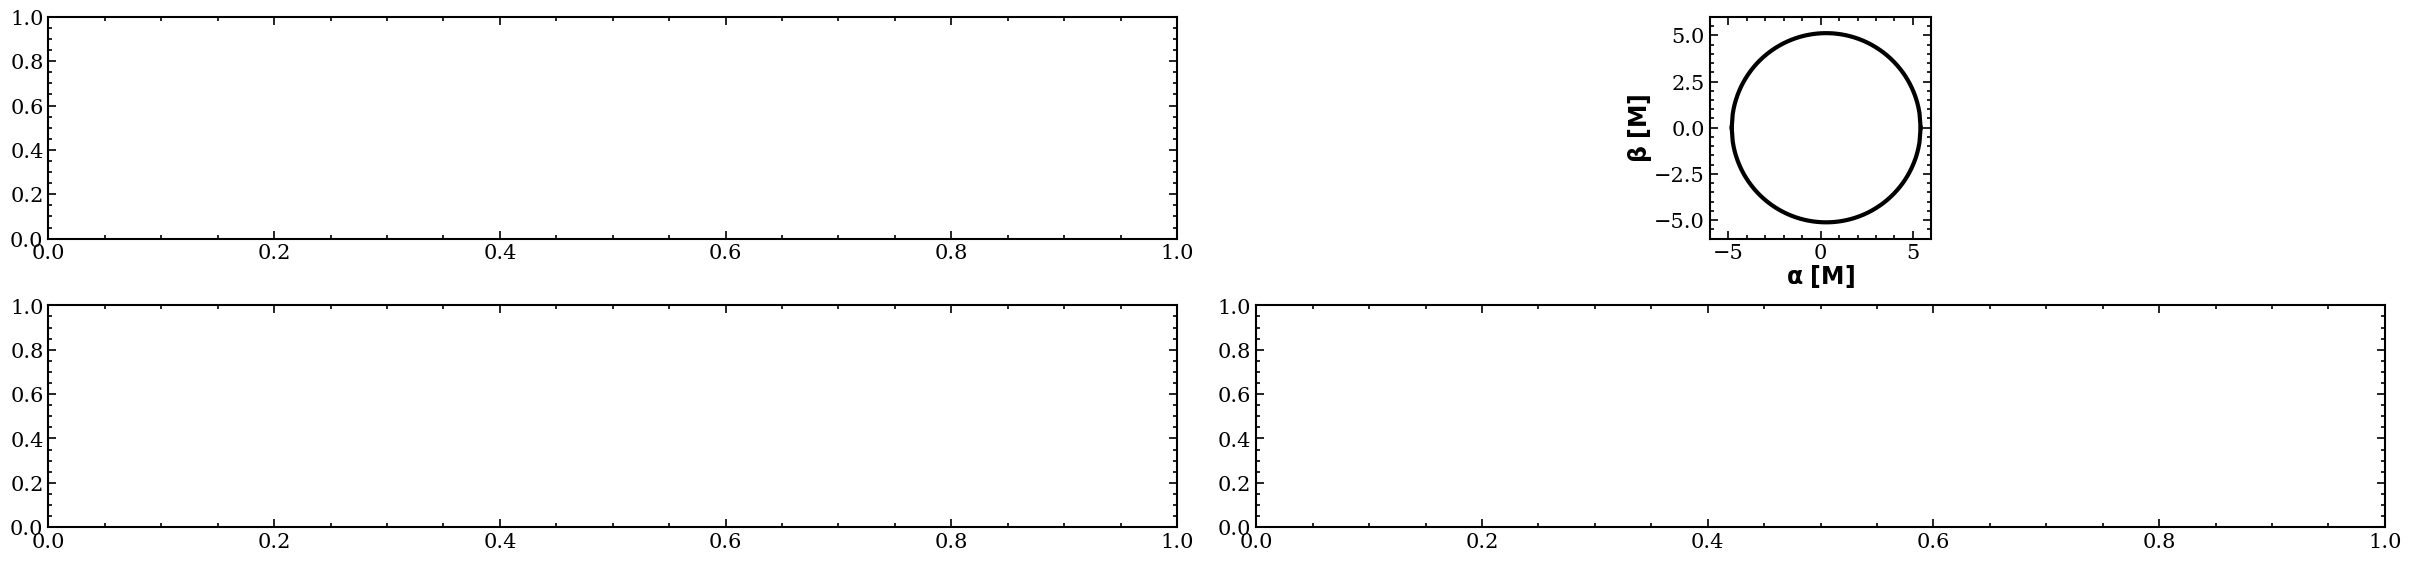

In [22]:
##################################################################################################################################################################################################################
#   EHT scatter+line plot style 
##################################################################################################################################################################################################################

figsize=(8.*3, 5.5) #size of the figure for general figures
rcParams['font.size']=15
rcParams['text.usetex']=False
rcParams['font.family']='serif'
plt.rc('text.latex', preamble=r'\usepackage{amsmath, amssymb, bm, braket, mathrsfs, newtxmath, newtxtext, slashed}')

# axes and tickmarks
rcParams['axes.labelsize']=17
#rcParams['axes.labelweight']=600
rcParams['axes.linewidth']=1.5

rcParams['xtick.labelsize']=15
rcParams['xtick.top']=True
rcParams['xtick.direction']='in'
rcParams['xtick.major.size']=6
rcParams['xtick.minor.size']=3
rcParams['xtick.major.width']=1.2
rcParams['xtick.minor.width']=1.2
rcParams['xtick.minor.visible']=True

rcParams['ytick.labelsize']=15
rcParams['ytick.right']=True
rcParams['ytick.direction']='in'
rcParams['ytick.major.size']=6
rcParams['ytick.minor.size']=3
rcParams['ytick.major.width']=1.2
rcParams['ytick.minor.width']=1.2
rcParams['ytick.minor.visible']=True

# points, errorbars, and lines
rcParams['lines.linewidth']=2.0
rcParams['lines.markeredgewidth']=0.5
rcParams['lines.markersize']=6
rcParams['errorbar.capsize']=2

from matplotlib.patches import Rectangle

plt.rcParams.update()

##################################################################################################################################################################################################################
# Figure Setgamma
##################################################################################################################################################################################################################

fig = plt.figure(figsize=figsize, constrained_layout=True)

import matplotlib.gridspec as gridspec

gs_Fig = gridspec.GridSpec(2, 2, figure=fig, width_ratios=[1, 1], wspace=None, hspace=None)

ax_Shadow = fig.add_subplot(gs_Fig[0,0])
ax_gamma  = fig.add_subplot(gs_Fig[0,1])
ax_tau    = fig.add_subplot(gs_Fig[1,0])
ax_delta  = fig.add_subplot(gs_Fig[1,1])

colorset = ['black', 'firebrick', 'midnightblue', 'darkgreen', 'purple']

#########################################################################################################
#########################################################################################################

ax_gamma.set_xlabel(r'${\bf \alpha\ [M]}$', labelpad=0)
ax_gamma.set_ylabel(r'${\bf \beta\ [M]}$',  labelpad=0)

ax_gamma.set_aspect(1.)

ax_gamma.set_xlim([-6., 6.])
ax_gamma.set_ylim([-6., 6.])


Shadow_Boundary_Curve_Plot_posB, = ax_gamma.plot(KHZM4_Crit_Params_alpha, +KHZM4_Crit_Params_beta, c=colorset[0], ls='-',  lw=3)
Shadow_Boundary_Curve_Plot_negB, = ax_gamma.plot(KHZM4_Crit_Params_alpha, -KHZM4_Crit_Params_beta, c=colorset[0], ls='-',  lw=3)

# ax_gamma.legend(handles = [Shadow_Boundary_Curve_Plot, KN_plot, KS_plot, KB_plot, KH_plot], 
#                 loc='lower left', ncol=2, columnspacing=0.75, framealpha=0.5, borderaxespad=.3)

#########################################################################################################
#########################################################################################################

# ax_tau.set_xlabel(r'${\bf Inclination, \mathscr{i}\ [\pi]}$', labelpad=0)
# ax_tau.set_ylabel(r'${\bf \langle\bar{\tau}\rangle_\psi}$',   labelpad=0)

# ax_tau.set_xlim([0., 0.5])
# ax_tau.set_ylim([-0.05, 0.01])

# ax_tau.plot(inc_List_K_adot5,         bar_tau_mean_psi_List_K_adot5,        c=colorset[0], ls='-',  lw=3)
# ax_tau.plot(inc_List_KN_adot5_qdot4,  bar_tau_mean_psi_List_KN_adot5_qdot4, c=colorset[1], ls='--', lw=3)
# ax_tau.plot(inc_List_KB_adot5_qdot4,  bar_tau_mean_psi_List_KB_adot5_qdot4, c=colorset[2], ls='-',  lw=3)
# ax_tau.plot(inc_List_KH_adot5_qdot4,  bar_tau_mean_psi_List_KH_adot5_qdot4, c=colorset[3], ls='-',  lw=3)
# ax_tau.plot(inc_List_KS_adot5_qdot4,  bar_tau_mean_psi_List_KS_adot5_qdot4, c=colorset[4], ls=':',  lw=4)

# #########################################################################################################
# #########################################################################################################

# ax_delta.set_xlabel(r'${\bf Inclination, \mathscr{i}\ [\pi]}$',         labelpad=0)
# ax_delta.set_ylabel(r'${\bf \langle\bar{\delta}\rangle_\psi\ mod\ 2}$', labelpad=0)

# ax_delta.set_xlim([0., 0.5])
# # ax_delta.set_ylim([0.0, 0.8])

# ax_delta.plot(inc_List_K_adot5,         bar_delta_mean_psi_List_K_adot5,        c=colorset[0], ls='-',  lw=3)
# ax_delta.plot(inc_List_KN_adot5_qdot4,  bar_delta_mean_psi_List_KN_adot5_qdot4, c=colorset[1], ls='--', lw=3)
# ax_delta.plot(inc_List_KB_adot5_qdot4,  bar_delta_mean_psi_List_KB_adot5_qdot4, c=colorset[2], ls='-',  lw=3)
# ax_delta.plot(inc_List_KH_adot5_qdot4,  bar_delta_mean_psi_List_KH_adot5_qdot4, c=colorset[3], ls='-',  lw=3)
# ax_delta.plot(inc_List_KS_adot5_qdot4,  bar_delta_mean_psi_List_KS_adot5_qdot4, c=colorset[4], ls=':',  lw=4)

# ############################################################################################################################################

# xt0, yt0 = 0.02, 0.23
# xt1, yt1 = 0.02, 0.90
# xt2, yt2 = 0.02, 0.90
# xt3, yt3 = 0.02, 0.90

# ax_gamma.text(xt0, yt0, r'${\bf Spin,\ a=0.5M}$',                                       verticalalignment='bottom', horizontalalignment='left', transform=ax_gamma.transAxes, fontsize=20)
# ax_gamma.text(xt1, yt1, r'${\bf Mean\ Scaling\ Exponent\ Deviation\ (from\ Schw.)}$',   verticalalignment='bottom', horizontalalignment='left', transform=ax_gamma.transAxes, fontsize=20)
# ax_tau.text(  xt2, yt2, r'${\bf Mean\ Delay\ Time\ Deviation}$',                        verticalalignment='bottom', horizontalalignment='left', transform=ax_tau.transAxes,   fontsize=20)
# ax_delta.text(xt3, yt3, r'${\bf Mean\ Rotation\ Parameter\ Deviation}$',                verticalalignment='bottom', horizontalalignment='left', transform=ax_delta.transAxes, fontsize=20)

############################################################################################################################################
############################################################################################################################################

# fig.tight_layout()
fig.savefig('./Figures/Fig3_KHZM4_Shadow.png',
            format='png',
            dpi=100,
            bbox_inches='tight')

In [23]:
# warnings.filterwarnings("ignore")

# ###################################################################################################################################

# l_Val = 0.4
# a_Max_Val = a_Max([0., l_Val])

# num_points = 100

# inc_List = (np.linspace(0., 0.5, 200, endpoint=False)[1:])*np.pi
# a_List = [0.001, 0.01, 0.1, 0.5, a_Max_Val-0.1, a_Max_Val-0.01, a_Max_Val-0.001]

# ###################################################################################################################################

# list_of_a_Data_Lists = []

# for i in range(len(a_List)):
#     a_Data_List_Dum = [[
#         'inc', 
#         ########################################################################
#         'rho_med_r',    'kappa_med_r',    'gamma_med_r',    'tau_med_r',    'delta_med_r',    'delta_mod_med_r', 
#         'rho_mean_r',   'kappa_mean_r',   'gamma_mean_r',   'tau_mean_r',   'delta_mean_r',   'delta_mod_mean_r', 
#         'rho_Max_r',    'kappa_Max_r',    'gamma_Max_r',    'tau_Max_r',    'delta_Max_r',    'delta_mod_Max_r', 
#         'rho_Min_r',    'kappa_Min_r',    'gamma_Min_r',    'tau_Min_r',    'delta_Min_r',    'delta_mod_Min_r', 
#         ########################################################################
#         'rho_med_psi',  'kappa_med_psi',  'gamma_med_psi',  'tau_med_psi',  'delta_med_psi',  'delta_mod_med_psi',
#         'rho_mean_psi', 'kappa_mean_psi', 'gamma_mean_psi', 'tau_mean_psi', 'delta_mean_psi', 'delta_mod_mean_psi',
#         'rho_Max_psi',  'kappa_Max_psi',  'gamma_Max_psi',  'tau_Max_psi',  'delta_Max_psi',  'delta_mod_Max_psi',
#         'rho_Min_psi',  'kappa_Min_psi',  'gamma_Min_psi',  'tau_Min_psi',  'delta_Min_psi',  'delta_mod_Min_psi'
#     ]]
#     list_of_a_Data_Lists.append(a_Data_List_Dum)

# with alive_bar(len(inc_List), force_tty=True) as bar:
#     for i in range(0, len(inc_List)):
#         inc_Val = inc_List[i]  
#         for j in range(0, len(a_List)):
#             metric_params_Val = [a_List[j], l_Val]
#             list_of_a_Data_Lists[j].append([inc_Val]+median_r(inc_Val, metric_params_Val, 50)+median_psi(inc_Val, metric_params_Val, 200))
#         bar()

# for j in range(len(a_List)):
#     a_Val     = str(a_List[j])
#     a_Val_str = a_Val.replace('.', 'dot')
#     file_name_str = "./Data/Fig1_KHZM4_ldot4_crit_exps_meds_means_r_psi_inc_File_a" + a_Val_str + ".csv"
#     crit_exps_meds_r_psi_inc_File_a = open(file_name_str, 'w+', newline ='')
#     with crit_exps_meds_r_psi_inc_File_a:    
#         write = csv.writer(crit_exps_meds_r_psi_inc_File_a)
#         write.writerows(list_of_a_Data_Lists[j])

In [24]:
# warnings.filterwarnings("ignore")

# ###################################################################################################################################

# l_Val = 0.4
# a_Max_Val = a_Max([0., l_Val])

# num_points = 100

# inc_List = (np.linspace(0., 0.5, num_points, endpoint=False)[1:])*np.pi
# a_List   = np.linspace(0., a_Max_Val, num_points)[1:]

# ###################################################################################################################################

# inc_a_List = []

# for i in range(0, len(inc_List)):
#     for j in range(0, len(a_List)):
#         inc_a_List.append([inc_List[i], a_List[j]])
        
# ####################################################################################################################################
# ####################################################################################################################################

# KHZM4_Crit_Exps_medians_a_inc_List = [[
#     'inc', 'a', 'rH', 'rPS_Min', 'rPS_Max',
#     ########################################################################
#     'rho_med_r',    'kappa_med_r',    'gamma_med_r',    'tau_med_r',    'delta_med_r',    'delta_mod_med_r', 
#     'rho_mean_r',   'kappa_mean_r',   'gamma_mean_r',   'tau_mean_r',   'delta_mean_r',   'delta_mod_mean_r', 
#     'rho_Max_r',    'kappa_Max_r',    'gamma_Max_r',    'tau_Max_r',    'delta_Max_r',    'delta_mod_Max_r', 
#     'rho_Min_r',    'kappa_Min_r',    'gamma_Min_r',    'tau_Min_r',    'delta_Min_r',    'delta_mod_Min_r', 
#     ########################################################################
#     'rho_med_psi',  'kappa_med_psi',  'gamma_med_psi',  'tau_med_psi',  'delta_med_psi',  'delta_mod_med_psi',
#     'rho_mean_psi', 'kappa_mean_psi', 'gamma_mean_psi', 'tau_mean_psi', 'delta_mean_psi', 'delta_mod_mean_psi',
#     'rho_Max_psi',  'kappa_Max_psi',  'gamma_Max_psi',  'tau_Max_psi',  'delta_Max_psi',  'delta_mod_Max_psi',
#     'rho_Min_psi',  'kappa_Min_psi',  'gamma_Min_psi',  'tau_Min_psi',  'delta_Min_psi',  'delta_mod_Min_psi'
# ]]

# # if __name__ == '__main__':
# #     with Pool(10) as p:
# #         KHZM4_Crit_Exps_medians_a_inc_List = p.map(defs_KHZM4_Crit_Exps_Data_Parallel.median_figure_task, inc_a_List)

# import defs_KHZM4_Crit_Exps_Data_Parallel
# from multiprocessing import Pool
# import tqdm
# from time import sleep

# if __name__ == '__main__':
#     pool = Pool(processes=10)
#     for k in tqdm.tqdm(pool.imap_unordered(defs_KHZM4_Crit_Exps_Data_Parallel.median_figure_task, inc_a_List), total=len(inc_a_List)):
#         KHZM4_Crit_Exps_medians_a_inc_List.append(k)
#         pass
    
# ############################################################################################################################################

# KHZM4_Crit_Exps_medians_a_inc_File = open('./Data/Fig2_KHZM4_ldot4_Crit_Exps_medians_a_inc.csv', 'w+', newline ='')
# with KHZM4_Crit_Exps_medians_a_inc_File:    
#     write = csv.writer(KHZM4_Crit_Exps_medians_a_inc_File)
#     write.writerows(KHZM4_Crit_Exps_medians_a_inc_List) 

In [25]:
# warnings.filterwarnings("ignore")

# ###################################################################################################################################

# a_Val = 0.5
# l_Max_Val = l_Max([a_Val, 0.])
# num_points = 100
# l_List = np.linspace(0., l_Max_Val, num_points)[1:]

# inc_List = [17.*(np.pi/180.), 89.*(np.pi/180.)]

# ###################################################################################################################################

# KHZM4_adot5_Crit_Exps_Meds_Means_psi_17deg_89deg_q = []

# with alive_bar(len(l_List), force_tty=True) as bar:
#     for i in range(0, len(l_List)):
#         l_Val = l_List[i]  
#         metric_params_Val = [a_Val, l_Val]
#         KHZM4_adot5_Crit_Exps_Meds_Means_psi_17deg_89deg_q.append(metric_params_Val+[inc_List[0]]+median_psi(inc_List[0], metric_params_Val, 200)+[inc_List[1]]+median_psi(inc_List[1], metric_params_Val, 200))
#         bar()

# KHZM4_adot5_Crit_Exps_Meds_Means_psi_17deg_89deg_l_w_heads = np.append([[
#     'a', 'q',
#     ########################################################################
#     'inc_17', 
#     ########################################################################
#     'rho_med_psi_17',  'kappa_med_psi_17',  'gamma_med_psi_17',  'tau_med_psi_17',  'delta_med_psi_17',  'delta_mod_med_psi_17',
#     'rho_mean_psi_17', 'kappa_mean_psi_17', 'gamma_mean_psi_17', 'tau_mean_psi_17', 'delta_mean_psi_17', 'delta_mod_mean_psi_17',
#     'rho_Max_psi_17',  'kappa_Max_psi_17',  'gamma_Max_psi_17',  'tau_Max_psi_17',  'delta_Max_psi_17',  'delta_mod_Max_psi_17',
#     'rho_Min_psi_17',  'kappa_Min_psi_17',  'gamma_Min_psi_17',  'tau_Min_psi_17',  'delta_Min_psi_17',  'delta_mod_Min_psi_17',
#     ########################################################################
#     'inc_89', 
#     ########################################################################
#     'rho_med_psi_89',  'kappa_med_psi_89',  'gamma_med_psi_89',  'tau_med_psi_89',  'delta_med_psi_89',  'delta_mod_med_psi_89',
#     'rho_mean_psi_89', 'kappa_mean_psi_89', 'gamma_mean_psi_89', 'tau_mean_psi_89', 'delta_mean_psi_89', 'delta_mod_mean_psi_89',
#     'rho_Max_psi_89',  'kappa_Max_psi_89',  'gamma_Max_psi_89',  'tau_Max_psi_89',  'delta_Max_psi_89',  'delta_mod_Max_psi_89',
#     'rho_Min_psi_89',  'kappa_Min_psi_89',  'gamma_Min_psi_89',  'tau_Min_psi_89',  'delta_Min_psi_89',  'delta_mod_Min_psi_89'
# ]], KHZM4_adot5_Crit_Exps_Meds_Means_psi_17deg_89deg_q, axis=0)

# KHZM4_adot5_Crit_Exps_Meds_Means_psi_17deg_89deg_l_File = open('./Data/FigB1_KHZM4_adot5_Crit_Exps_Meds_Means_psi_17deg_89deg_l_File.csv', 'w+', newline ='')
# with KHZM4_adot5_Crit_Exps_Meds_Means_psi_17deg_89deg_l_File:    
#     write = csv.writer(KHZM4_adot5_Crit_Exps_Meds_Means_psi_17deg_89deg_l_File)
#     write.writerows(KHZM4_adot5_Crit_Exps_Meds_Means_psi_17deg_89deg_l_w_heads)